# Operaciones básicas con imágenes - actividad breve

En este cuaderno se resuelve la actividad breve del archivo `004b`, repitiendo las operaciones con otro recorte de la misma imagen para observar cómo cambian el tamaño y la orientación.

## Objetivo

Aplicar recorte, redimensionado, volteo y rotación sobre una nueva región de `small-boats_1.jpg`, y describir qué cambia en cada caso.

## Resultados de aprendizaje

- seleccionar un nuevo recorte mediante coordenadas de filas y columnas;
- comparar visualmente el efecto del redimensionado;
- distinguir conceptualmente entre voltear y rotar una imagen.

## Módulos que vamos a usar

- `cv2`: para leer, redimensionar, voltear y rotar imágenes.
- `matplotlib.pyplot`: para mostrar comparaciones.
- `pathlib.Path`: para ubicar la imagen de trabajo.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

# Carga la misma imagen usada en el cuaderno base para repetir las operaciones con otro recorte.
ruta_imagen = Path("Imagenes") / "small-boats_1.jpg"
imagen_bgr = cv2.imread(str(ruta_imagen), cv2.IMREAD_COLOR)
if imagen_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_imagen}")

# Convierte la imagen a RGB para visualizarla correctamente con matplotlib.
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
alto, ancho, canales = imagen_rgb.shape

print(f"Alto: {alto}")
print(f"Ancho: {ancho}")
print(f"Canales: {canales}")

Alto: 795
Ancho: 1200
Canales: 3


## 1. Imagen original

Primero conviene mirar la escena completa para elegir un recorte distinto del usado en `004b`.

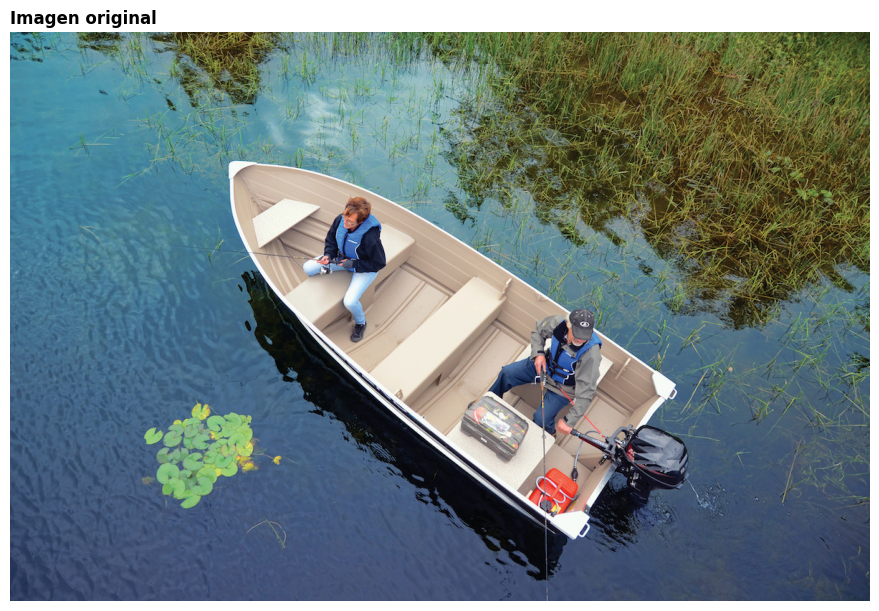

In [2]:
# Muestra la imagen completa como referencia antes de seleccionar una nueva región.
plt.figure(figsize=(9, 6), constrained_layout=True)
plt.imshow(imagen_rgb)
plt.title("Imagen original", fontweight="bold", loc="left")
plt.axis("off")
plt.show()

## 2. Nuevo recorte

En esta resolución se elige una región distinta, más centrada sobre la zona de la embarcación y las personas, para que los cambios de orientación se perciban con claridad.

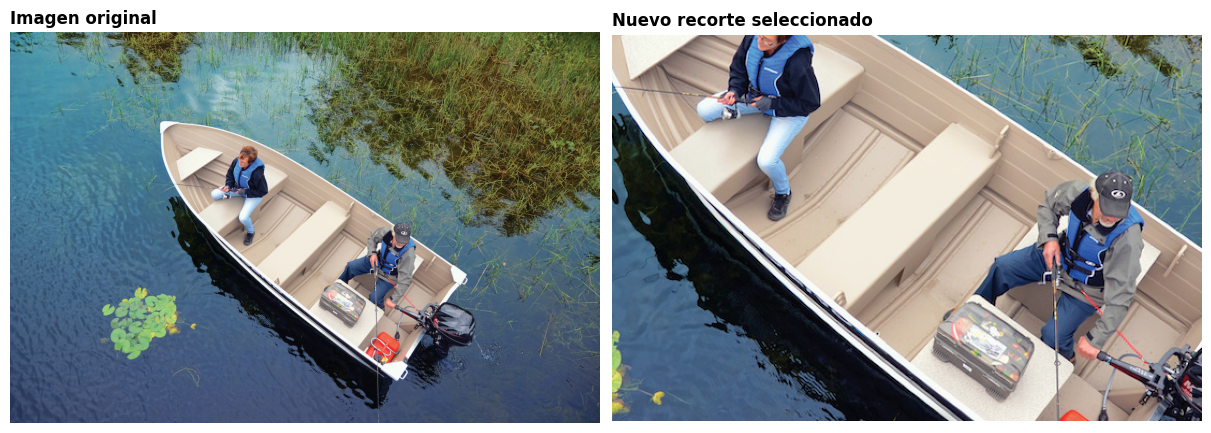

In [3]:
# Define un nuevo recorte usando filas y columnas diferentes a las del cuaderno original.
fila_inicial = 260
fila_final = 620
columna_inicial = 330
columna_final = 880

# Extrae la nueva región de interés de la imagen original.
imagen_recortada = imagen_rgb[fila_inicial:fila_final, columna_inicial:columna_final]

fig, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
ejes[0].imshow(imagen_rgb)
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(imagen_recortada)
ejes[1].set_title("Nuevo recorte seleccionado", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()

## 3. Redimensionar

Redimensionar cambia el tamaño del recorte. Si la nueva relación entre ancho y alto no coincide con la original, la imagen también puede verse estirada o comprimida.

Tamaño del recorte original: (360, 550, 3)
Tamaño del recorte redimensionado: (420, 700, 3)


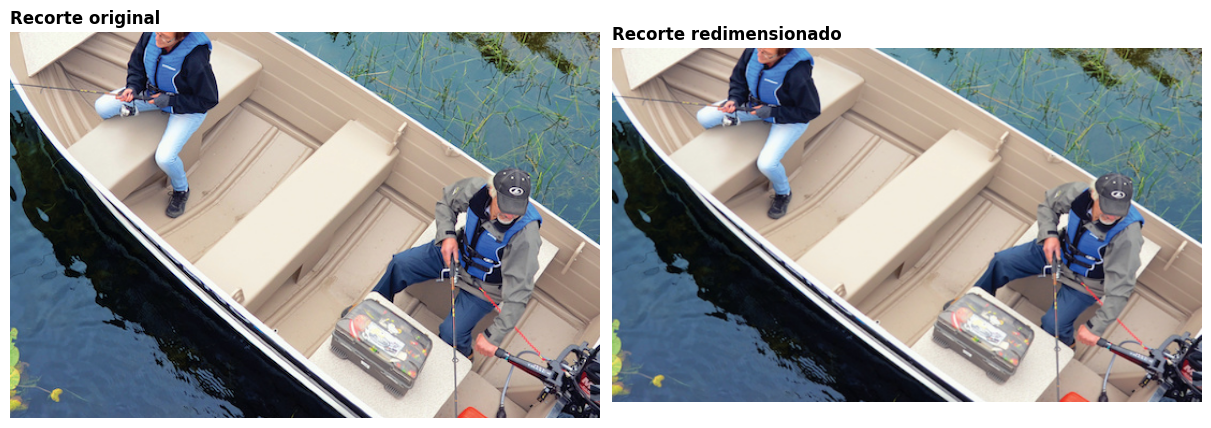

In [4]:
# Cambia el tamaño del recorte para comparar su escala con la región original.
imagen_redimensionada = cv2.resize(imagen_recortada, (700, 420))

# Muestra las dimensiones para verificar numéricamente el cambio de tamaño.
print(f"Tamaño del recorte original: {imagen_recortada.shape}")
print(f"Tamaño del recorte redimensionado: {imagen_redimensionada.shape}")

fig, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
ejes[0].imshow(imagen_recortada)
ejes[0].set_title("Recorte original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(imagen_redimensionada)
ejes[1].set_title("Recorte redimensionado", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()

## 4. Voltear

Voltear genera un reflejo de la imagen respecto de un eje. El contenido sigue siendo el mismo, pero cambia la orientación espacial.

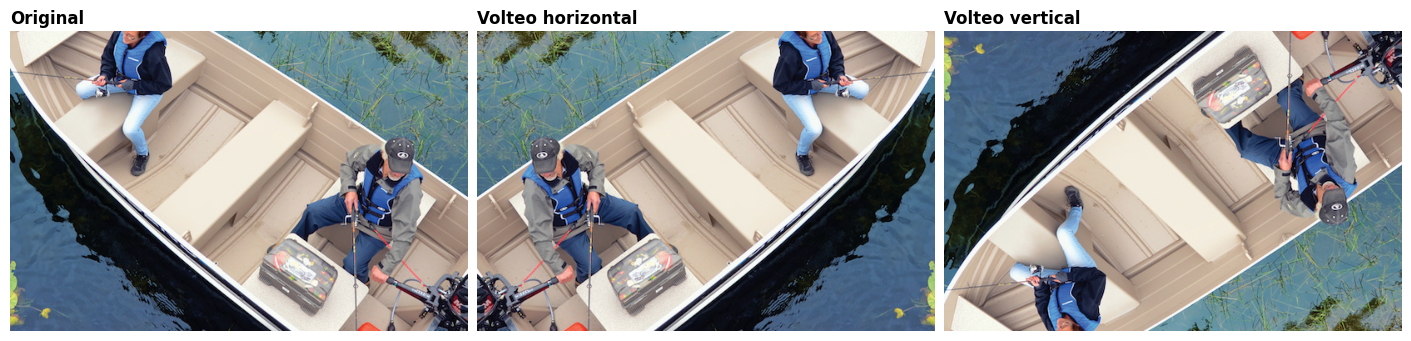

In [5]:
# Genera una versión reflejada horizontalmente y otra verticalmente.
imagen_volteada_horizontal = cv2.flip(imagen_recortada, 1)
imagen_volteada_vertical = cv2.flip(imagen_recortada, 0)

fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
ejes[0].imshow(imagen_recortada)
ejes[0].set_title("Original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(imagen_volteada_horizontal)
ejes[1].set_title("Volteo horizontal", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(imagen_volteada_vertical)
ejes[2].set_title("Volteo vertical", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()

## 5. Rotar

Rotar cambia la orientación angular de la imagen alrededor de un punto de referencia. A diferencia del volteo, no produce un reflejo, sino un giro.

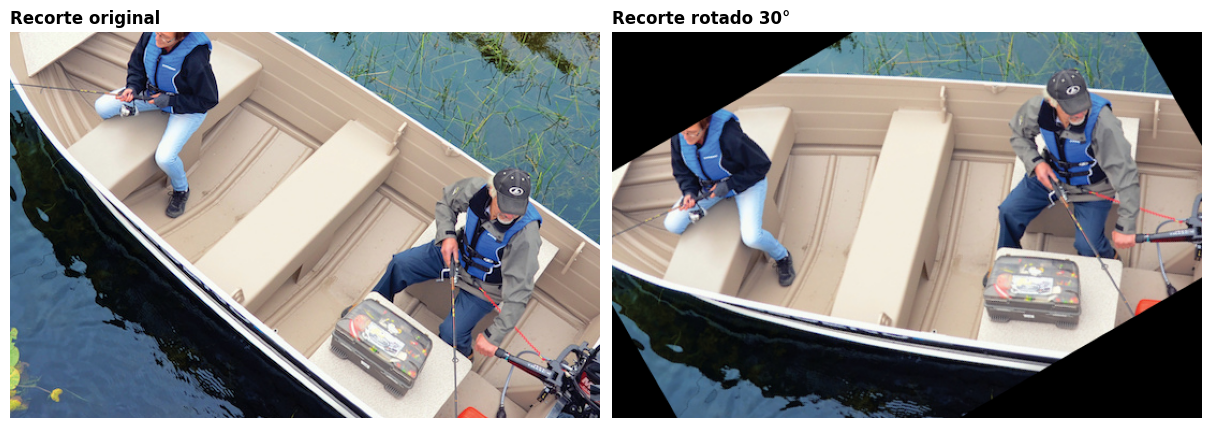

In [6]:
# Calcula la matriz de rotación usando el centro del nuevo recorte.
centro = (imagen_recortada.shape[1] // 2, imagen_recortada.shape[0] // 2)
matriz_rotacion = cv2.getRotationMatrix2D(centro, 30, 1.0)

# Aplica la rotación manteniendo el mismo tamaño de salida que el recorte original.
imagen_rotada = cv2.warpAffine(
    imagen_recortada,
    matriz_rotacion,
    (imagen_recortada.shape[1], imagen_recortada.shape[0]),
)

fig, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
ejes[0].imshow(imagen_recortada)
ejes[0].set_title("Recorte original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(imagen_rotada)
ejes[1].set_title("Recorte rotado 30°", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()

## Resolución de la actividad breve

A continuación se responde la consigna a partir del nuevo recorte elegido.

### Respuestas

1. Las coordenadas usadas fueron `fila_inicial = 260`, `fila_final = 620`, `columna_inicial = 330` y `columna_final = 880`.
2. Al redimensionar, el recorte pasó a ocupar un nuevo tamaño y la escena se ve más amplia en pantalla. Además, como cambió la proporción respecto del recorte original, algunos elementos pueden percibirse un poco estirados.
3. La diferencia conceptual es que `voltear` refleja la imagen respecto de un eje horizontal o vertical, mientras que `rotar` la gira alrededor de un punto. En el volteo se invierte la orientación como en un espejo; en la rotación se conserva la estructura, pero cambia el ángulo de la escena.

## Cierre

Estas operaciones son simples, pero ayudan a entender que una imagen digital puede manipularse como una matriz. Elegir bien el recorte y distinguir entre reflejar y girar una escena es una base útil para transformaciones más complejas.